# Exploratory Data Analysis — Churn Prediction
## HPB Fintech Hackathon 2026

Analyse five source tables (clients, products, transactions, balances, contacts)
and build a **single-period feature set** with **10 features** per customer.

### Target
- **churned = 1** if the customer lost all core products (accounts + loans + deposits)
- **churned = 0** otherwise

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

COLORS = {'active': '#2ecc71', 'churned': '#e74c3c', 'primary': '#3498db', 'accent': '#f39c12'}
RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

CORE_DOMAINS = {'ACCOUNTS', 'LOANS', 'DEPOSITS'}
PLACEHOLDER_DATE = '1/1/2023/'

# ── EU-format parsing helpers ──
def parse_eu_date(s):
    return pd.to_datetime(s.str.strip().str.rstrip('/'), format='%d/%m/%Y', errors='coerce')

def parse_eu_datetime(s):
    return pd.to_datetime(
        s.str.strip().str.replace('/ ', ' ', regex=False),
        format='%d/%m/%Y %H:%M:%S', errors='coerce')

def eu_to_float(s):
    return pd.to_numeric(
        s.str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce')

print('Libraries loaded')

Libraries loaded


## 1. Load Source Tables

In [2]:
# ── Load all raw datasets (columns already in English) ──
clients = pd.read_csv(RAW / 'clients.csv', dtype=str)
clients['age'] = pd.to_numeric(clients['age'], errors='coerce')
clients['first_relationship_date'] = parse_eu_date(clients['first_relationship_date'])

products_raw = pd.read_csv(RAW / 'products.csv', dtype=str)

# ── Data quality fix: 1/1/2023/ placeholder → NaT ──
n_placeholder = (products_raw['closing_date'] == PLACEHOLDER_DATE).sum()
products_raw.loc[products_raw['closing_date'] == PLACEHOLDER_DATE, 'closing_date'] = np.nan
print(f'Data quality fix: treated {n_placeholder:,} products with 1/1/2023/ closure as still-active')

products_raw['opening_date'] = parse_eu_date(products_raw['opening_date'])
products_raw['closing_date'] = parse_eu_date(products_raw['closing_date'])

# Full product set (for features — counts ALL product types)
products = products_raw.copy()

# Core products only (for churn definition)
products_core = products[products['product_domain'].isin(CORE_DOMAINS)].copy()
print(f'Core products (Accounts+Loans+Deposits): {len(products_core):,} / {len(products):,} total')

transactions = pd.read_csv(RAW / 'transactions.csv', dtype=str)
transactions = transactions.loc[:, transactions.columns.notna()]
transactions['date'] = parse_eu_datetime(transactions['txn_datetime'])
transactions['amount'] = eu_to_float(transactions['amount'])

balances = pd.read_csv(RAW / 'balances.csv', dtype=str)
balances['balance'] = eu_to_float(balances['balance'])
balances['valid_from'] = parse_eu_date(balances['valid_from'])

contacts = pd.read_csv(RAW / 'contacts.csv', dtype=str)
contacts['date'] = parse_eu_datetime(contacts['created_at'])

prod_client = products[['product_id', 'client_id']].drop_duplicates()

for name, df in [('Clients', clients), ('Products', products),
                  ('  Core products', products_core),
                  ('Transactions', transactions), ('Balances', balances),
                  ('Contact Center', contacts)]:
    print(f'{name:20s} {df.shape[0]:>10,} rows x {df.shape[1]:>3} cols')

Data quality fix: treated 5,365 products with 1/1/2023/ closure as still-active
Core products (Accounts+Loans+Deposits): 20,218 / 58,703 total
Clients                  11,997 rows x  38 cols
Products                 58,703 rows x  13 cols
  Core products          20,218 rows x  13 cols
Transactions          1,048,575 rows x  12 cols
Balances                817,933 rows x   6 cols
Contact Center           23,605 rows x   6 cols


## 2. Data Availability Timeline

Date ranges per data source:
  Client relationships       1980-01-01  ->  2026-02-02
  Product openings           1980-01-01  ->  2026-04-14
  Transactions               2024-06-02  ->  2026-04-14
  Balances                   2010-04-13  ->  2026-04-14
  Contact Center             2013-04-19  ->  2026-04-15


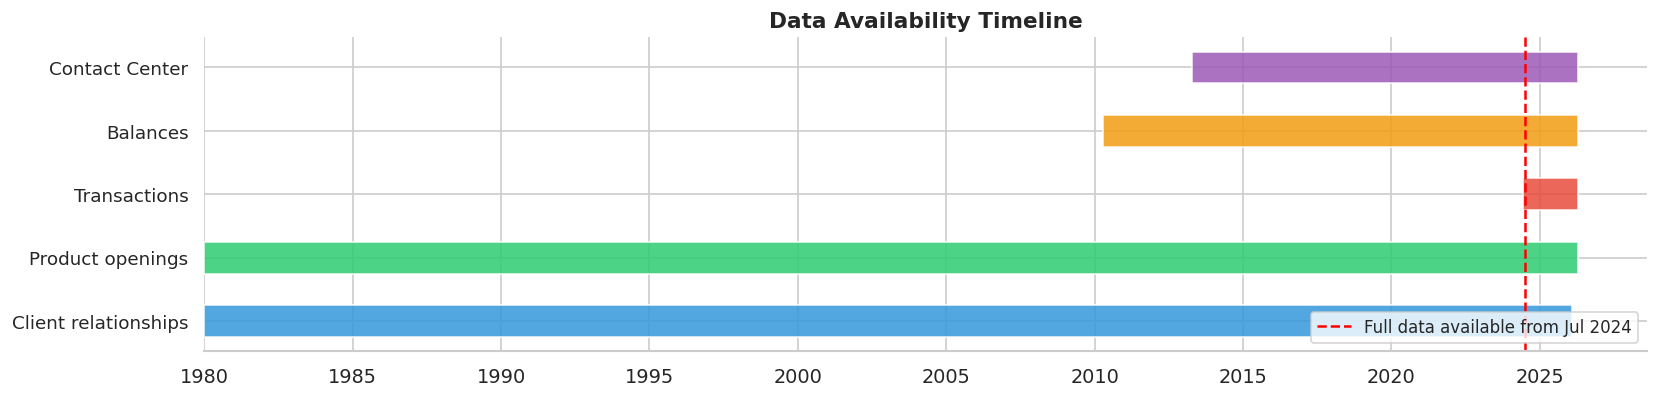


Transactions start June 2024 — this is our binding constraint.
All behavioral features must use data from July 2024 onward.


In [3]:
ranges = {
    'Client relationships': (clients['first_relationship_date'].min(), clients['first_relationship_date'].max()),
    'Product openings':     (products['opening_date'].min(), products['opening_date'].max()),
    'Transactions':         (transactions['date'].min(), transactions['date'].max()),
    'Balances':             (balances['valid_from'].min(), balances['valid_from'].max()),
    'Contact Center':       (contacts['date'].min(), contacts['date'].max()),
}
print('Date ranges per data source:')
for name, (mn, mx) in ranges.items():
    print(f'  {name:25s}  {mn.date()}  ->  {mx.date()}')

fig, ax = plt.subplots(figsize=(14, 3.5))
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
for i, (name, (mn, mx)) in enumerate(ranges.items()):
    ax.barh(i, mdates.date2num(mx) - mdates.date2num(mn),
            left=mdates.date2num(mn), color=colors_bar[i], alpha=0.85, height=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.set_yticks(range(len(ranges)))
ax.set_yticklabels(list(ranges.keys()), fontsize=11)
ax.axvline(mdates.date2num(pd.Timestamp('2024-07-01')), color='red', ls='--', lw=1.5,
           label='Full data available from Jul 2024')
ax.legend(loc='lower right', fontsize=10)
ax.set_title('Data Availability Timeline', fontweight='bold', fontsize=13)
sns.despine(left=True)
plt.tight_layout()
plt.show()

print()
print('Transactions start June 2024 \u2014 this is our binding constraint.')
print('All behavioral features must use data from July 2024 onward.')

## 3. Product Closure Analysis

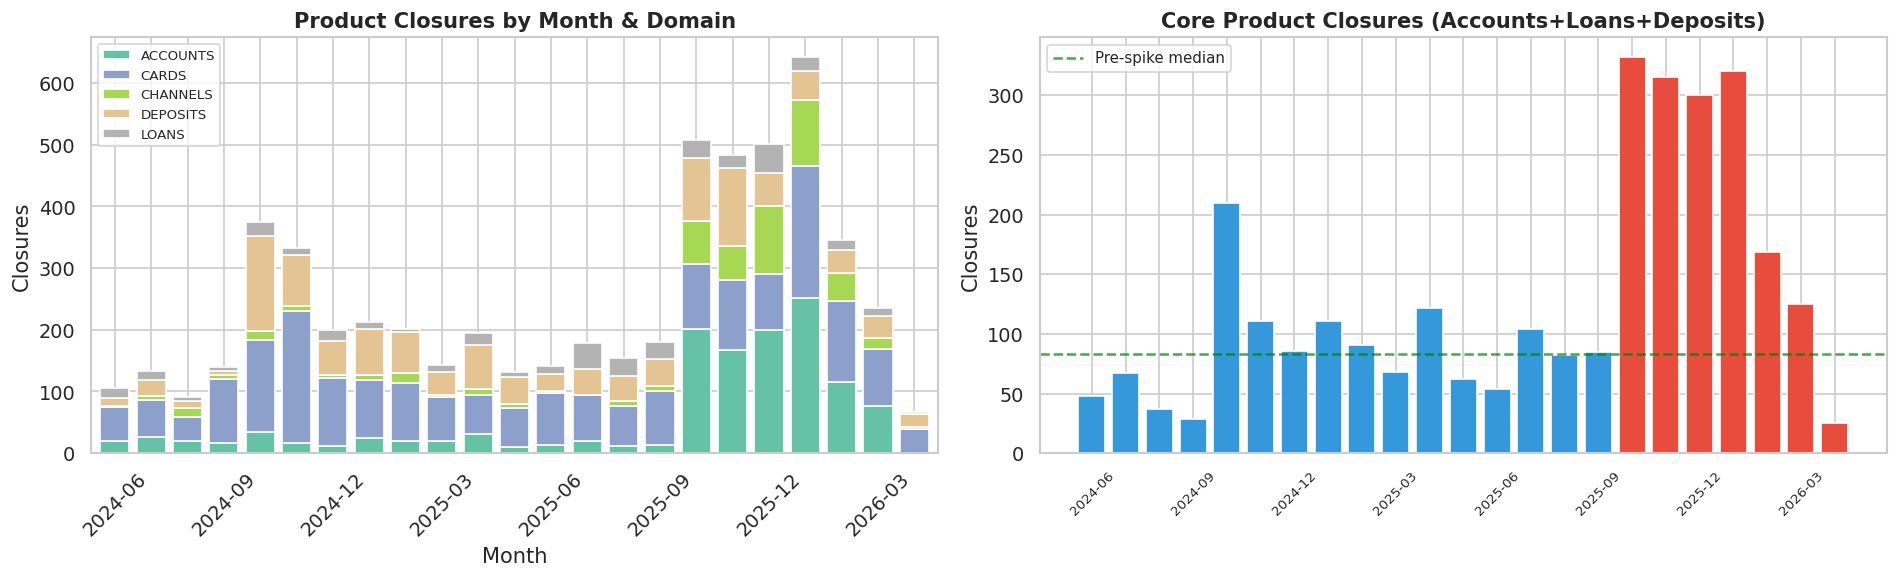

Pre-spike (Jun 2024 – Sep 2025): 2,917 closures, 182/month avg
Spike period (Oct 2025 – Mar 2026): 2,715 closures, 452/month avg

This regime change is real (closures spread across many dates, not batch).


In [4]:
# Monthly closure counts by domain \u2014 shows the regime change
closures = products[products['closing_date'].notna()].copy()
closures['close_month'] = closures['closing_date'].dt.to_period('M')
closures['domain'] = closures['product_domain']

# Pivot: month \u00d7 domain
pivot = closures[closures['close_month'].astype(str).between('2024-06', '2026-04')].groupby(
    ['close_month', 'domain']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all domains stacked
pivot.plot.bar(stacked=True, ax=axes[0], colormap='Set2', width=0.8)
axes[0].set_title('Product Closures by Month & Domain', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Closures')
axes[0].tick_params(axis='x', rotation=45)
for i, label in enumerate(axes[0].xaxis.get_ticklabels()):
    label.set_visible(i % 3 == 0)
axes[0].legend(fontsize=8, loc='upper left')
axes[0].axvline(pivot.index.get_loc(pd.Period('2025-10', 'M')) - 0.5,
                color='red', ls='--', lw=2, label='Spike start')

# Right: core products only
core_pivot = closures[
    closures['domain'].isin(CORE_DOMAINS) &
    closures['close_month'].astype(str).between('2024-06', '2026-04')
].groupby('close_month').size()

ax2 = axes[1]
colors_line = ['#3498db' if str(m) < '2025-10' else '#e74c3c' for m in core_pivot.index]
ax2.bar(range(len(core_pivot)), core_pivot.values, color=colors_line, width=0.8)
ax2.set_xticks(range(len(core_pivot)))
ax2.set_xticklabels([str(m) for m in core_pivot.index], rotation=45, fontsize=8)
for i, label in enumerate(ax2.xaxis.get_ticklabels()):
    label.set_visible(i % 3 == 0)
ax2.set_title('Core Product Closures (Accounts+Loans+Deposits)', fontweight='bold')
ax2.set_ylabel('Closures')
ax2.axhline(core_pivot[core_pivot.index.astype(str) < '2025-10'].median(),
            color='green', ls='--', lw=1.5, alpha=0.7, label='Pre-spike median')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary
pre_spike = closures[closures['close_month'].astype(str).between('2024-06', '2025-09')]
post_spike = closures[closures['close_month'].astype(str).between('2025-10', '2026-03')]
print(f'Pre-spike (Jun 2024 \u2013 Sep 2025): {len(pre_spike):,} closures, '
      f'{len(pre_spike)/16:.0f}/month avg')
print(f'Spike period (Oct 2025 \u2013 Mar 2026): {len(post_spike):,} closures, '
      f'{len(post_spike)/6:.0f}/month avg')
print(f'\nThis regime change is real (closures spread across many dates, not batch).')

## 4. Churn Labels (EDA)

In [5]:
# ── Compute churn labels for EDA ──
REF_VIZ = pd.Timestamp('2026-01-01')
CHURN_END_VIZ = pd.Timestamp('2026-03-31')

# At-risk: \u22651 active product of ANY type at ref_date
prods_at_ref = products[
    (products['opening_date'] <= REF_VIZ) &
    (products['closing_date'].isna() | (products['closing_date'] > REF_VIZ))
]
at_risk_ids = set(prods_at_ref['client_id'].unique())

# Churned: zero active CORE products at churn_end
core_at_end = products_core[
    (products_core['opening_date'] <= CHURN_END_VIZ) &
    (products_core['closing_date'].isna() | (products_core['closing_date'] > CHURN_END_VIZ))
]
core_active_end_ids = set(core_at_end['client_id'].unique())

# Also need: did client have core products at ref?
core_at_ref = products_core[
    (products_core['opening_date'] <= REF_VIZ) &
    (products_core['closing_date'].isna() | (products_core['closing_date'] > REF_VIZ))
]
had_core_at_ref = set(core_at_ref['client_id'].unique())

# At-risk = had ANY active product at ref. Churned = had core AND lost all core by end.
churned_ids = (at_risk_ids & had_core_at_ref) - core_active_end_ids
active_ids = at_risk_ids - churned_ids

labels = pd.DataFrame({
    'client_id': list(at_risk_ids),
    'churned': [1 if c in churned_ids else 0 for c in at_risk_ids]
})

eda_df = clients.merge(labels, on='client_id')
eda_df['tenure_years'] = (REF_VIZ - eda_df['first_relationship_date']).dt.days / 365.25

n_c = labels['churned'].sum()
n_a = len(labels) - n_c
print(f'At-risk population: {len(labels):,}')
print(f'  Churned: {n_c:,} ({n_c/len(labels):.1%})')
print(f'  Active:  {n_a:,} ({n_a/len(labels):.1%})')
print(f'\nNote: clients who only had Cards/Channels and lost them are NOT counted as churned.')
print(f'Clients with core products at ref: {len(had_core_at_ref):,}')

At-risk population: 7,805
  Churned: 131 (1.7%)
  Active:  7,674 (98.3%)

Note: clients who only had Cards/Channels and lost them are NOT counted as churned.
Clients with core products at ref: 3,627


## 5. Demographics by Churn Status

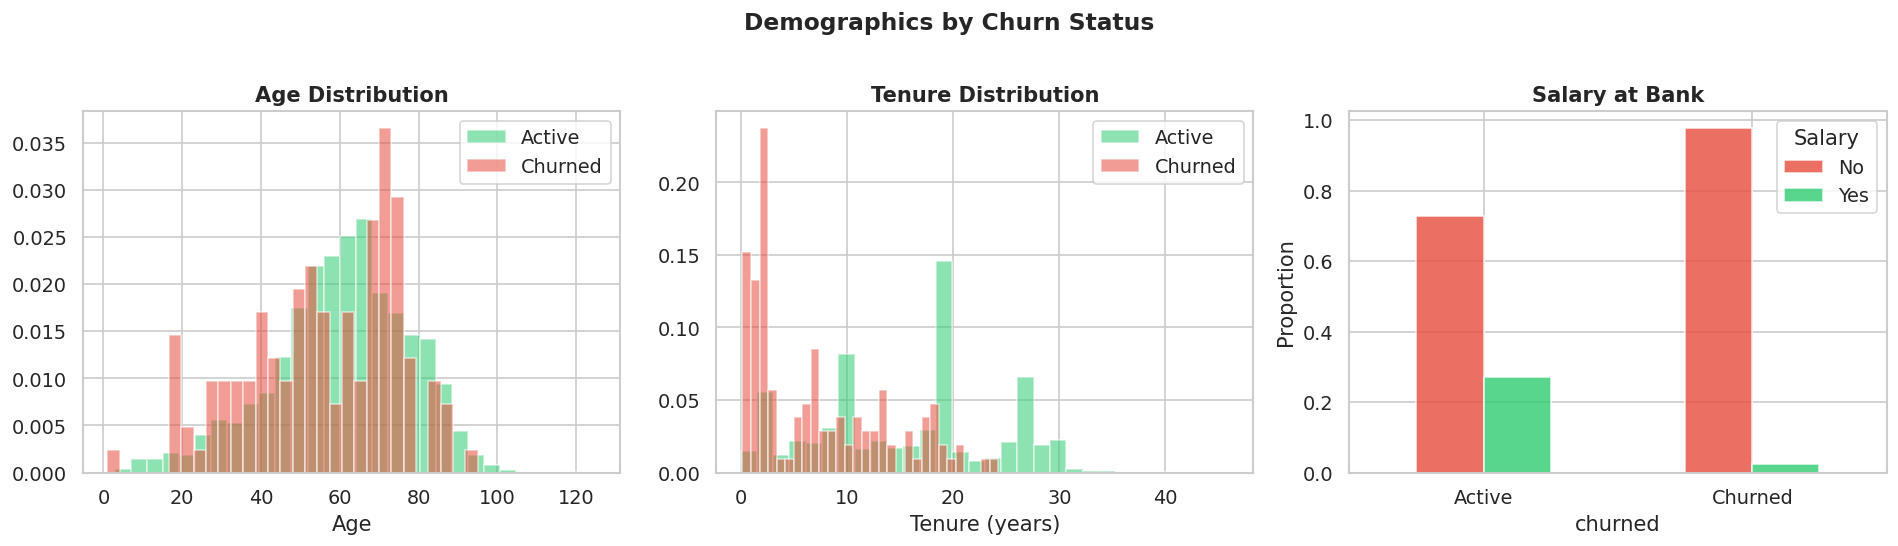

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Age distribution
for val, label, color in [(0, 'Active', COLORS['active']), (1, 'Churned', COLORS['churned'])]:
    subset = eda_df.loc[eda_df['churned'] == val, 'age'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.55, color=color, label=label, density=True)
axes[0].set_xlabel('Age')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].legend()

# Tenure
for val, label, color in [(0, 'Active', COLORS['active']), (1, 'Churned', COLORS['churned'])]:
    subset = eda_df.loc[eda_df['churned'] == val, 'tenure_years'].dropna()
    axes[1].hist(subset, bins=30, alpha=0.55, color=color, label=label, density=True)
axes[1].set_xlabel('Tenure (years)')
axes[1].set_title('Tenure Distribution', fontweight='bold')
axes[1].legend()

# Salary at bank
salary = eda_df.groupby(['churned', 'receives_salary_at_bank']).size().unstack(fill_value=0)
salary_pct = salary.div(salary.sum(axis=1), axis=0)
salary_pct.plot.bar(ax=axes[2], color=[COLORS['churned'], COLORS['active']], alpha=0.8)
axes[2].set_xticklabels(['Active', 'Churned'], rotation=0)
axes[2].set_title('Salary at Bank', fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].legend(['No', 'Yes'], title='Salary')

plt.suptitle('Demographics by Churn Status', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Products by Churn Status

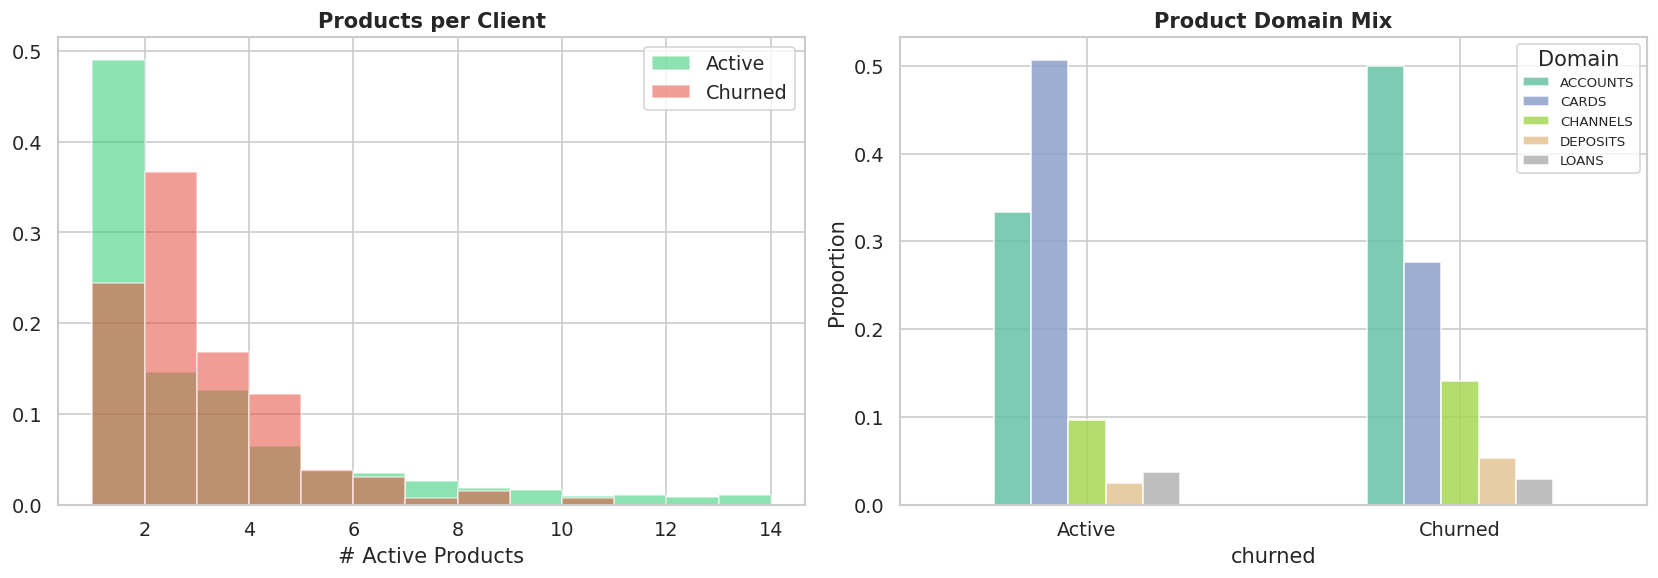

Median products - Active: 2, Churned: 2


In [7]:
# Product counts per client at reference date (all products)
prod_df = prods_at_ref.merge(labels, on='client_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Products per client by churn status
n_prods = prod_df.groupby('client_id').size().reset_index(name='n_products')
n_prods = n_prods.merge(labels, on='client_id')
for val, label, color in [(0, 'Active', COLORS['active']), (1, 'Churned', COLORS['churned'])]:
    sub = n_prods.loc[n_prods['churned'] == val, 'n_products']
    axes[0].hist(sub, bins=range(1, 15), alpha=0.55, color=color, label=label, density=True)
axes[0].set_xlabel('# Active Products')
axes[0].set_title('Products per Client', fontweight='bold')
axes[0].legend()

# Product domain breakdown by churn
domain_churn = prod_df.groupby(['churned', 'product_domain']).size().unstack(fill_value=0)
domain_pct = domain_churn.div(domain_churn.sum(axis=1), axis=0)
domain_pct.plot.bar(ax=axes[1], colormap='Set2', alpha=0.85)
axes[1].set_xticklabels(['Active', 'Churned'], rotation=0)
axes[1].set_title('Product Domain Mix', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].legend(fontsize=8, title='Domain')

plt.tight_layout()
plt.show()

n_per_group = n_prods.groupby('churned')['n_products'].median()
print(f'Median products - Active: {n_per_group.get(0, 0):.0f}, Churned: {n_per_group.get(1, 0):.0f}')

## 7. Transaction Analysis

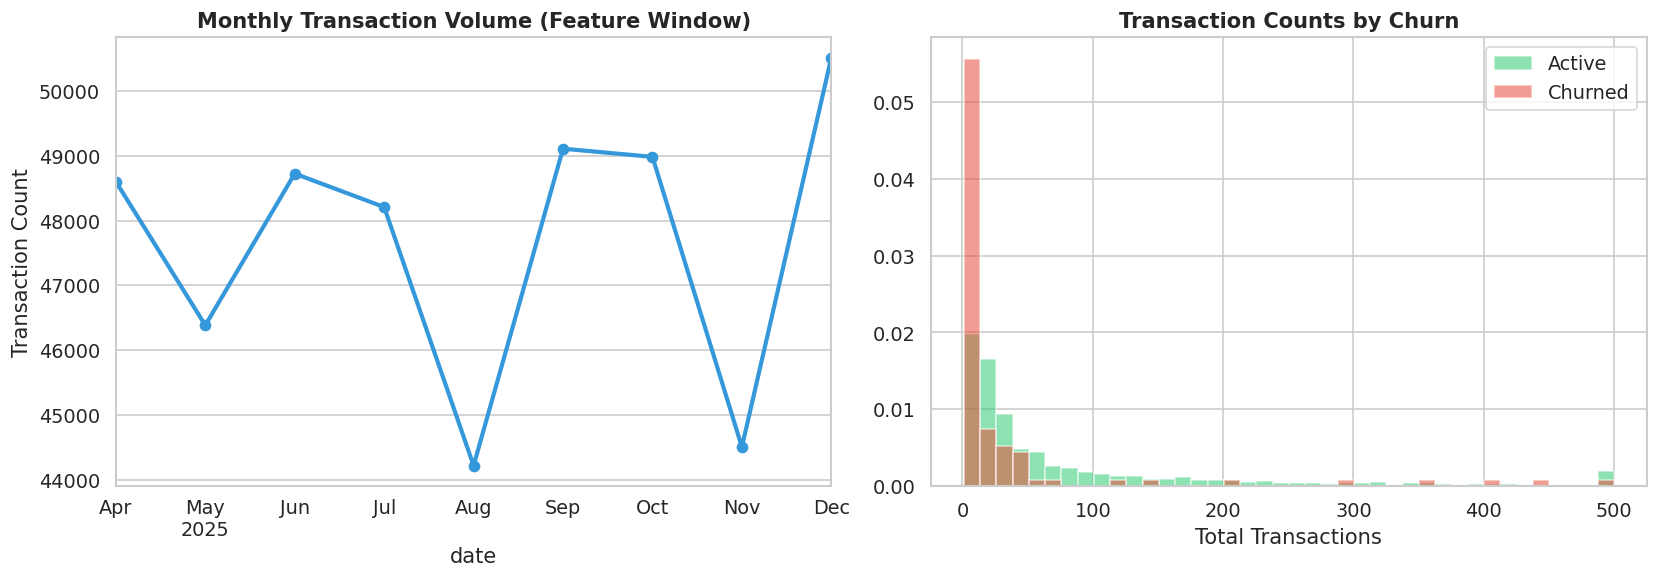

Active: median 30 txns, avg amount 118 EUR
Churned: median 9 txns, avg amount 133 EUR


In [8]:
# Monthly transaction volume for feature window (Apr-Dec 2025)
txn_w = transactions[(transactions['date'] >= '2025-04-01') & (transactions['date'] <= '2025-12-31')]
monthly = txn_w.set_index('date').resample('ME').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly.plot(ax=axes[0], color=COLORS['primary'], lw=2.5, marker='o')
axes[0].set_title('Monthly Transaction Volume (Feature Window)', fontweight='bold')
axes[0].set_ylabel('Transaction Count')

# Avg transaction amount by churn
txn_c = txn_w.merge(prod_client, on='product_id', how='left')
txn_c = txn_c.merge(labels, on='client_id', how='inner')
txn_agg = txn_c.groupby('client_id').agg(
    avg_amt=('amount', 'mean'),
    n_txn=('amount', 'size')
).reset_index().merge(labels, on='client_id')

for val, label, color in [(0, 'Active', COLORS['active']), (1, 'Churned', COLORS['churned'])]:
    sub = txn_agg.loc[txn_agg['churned'] == val, 'n_txn'].clip(upper=500)
    axes[1].hist(sub, bins=40, alpha=0.55, color=color, label=label, density=True)
axes[1].set_xlabel('Total Transactions')
axes[1].set_title('Transaction Counts by Churn', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

for val, label in [(0, 'Active'), (1, 'Churned')]:
    sub = txn_agg[txn_agg['churned'] == val]
    print(f'{label}: median {sub["n_txn"].median():.0f} txns, '
          f'avg amount {sub["avg_amt"].median():.0f} EUR')

## 8. Feature Engineering (Single Period, 10 Features)

In [9]:
# ── Feature Engineering \u2014 Single Period (Latest) ──
FEAT_START = pd.Timestamp('2025-04-01')
FEAT_END   = pd.Timestamp('2025-12-31')
REF        = pd.Timestamp('2026-01-01')
CHURN_END  = pd.Timestamp('2026-03-31')

# ── Population (ANY active product at ref) ──
prods_ref = products[
    (products['opening_date'] <= REF) &
    (products['closing_date'].isna() | (products['closing_date'] > REF))
]
risk_ids = set(prods_ref['client_id'].unique())

# ── Labels: churn defined by CORE products ──
core_ref = products_core[
    (products_core['opening_date'] <= REF) &
    (products_core['closing_date'].isna() | (products_core['closing_date'] > REF))
]
had_core_ids = set(core_ref['client_id'].unique())

core_end = products_core[
    (products_core['opening_date'] <= CHURN_END) &
    (products_core['closing_date'].isna() | (products_core['closing_date'] > CHURN_END))
]
core_active_end = set(core_end['client_id'].unique())
churned = (risk_ids & had_core_ids) - core_active_end

feat = pd.DataFrame({'client_id': list(risk_ids)})
feat['churned'] = feat['client_id'].isin(churned).astype(int)

n_c = feat['churned'].sum()
print(f'At-risk population: {len(feat):,}')
print(f'  Churned: {n_c:,} ({n_c/len(feat):.1%})')
print(f'  Active:  {len(feat)-n_c:,} ({(len(feat)-n_c)/len(feat):.1%})')

# ── 1. tenure_years ──
kl = clients[['client_id', 'first_relationship_date']].copy()
kl['tenure_years'] = (REF - kl['first_relationship_date']).dt.days / 365.25
feat = feat.merge(kl[['client_id', 'tenure_years']], on='client_id', how='left')

# ── 2. n_products ──
n_pr = prods_ref.groupby('client_id').size().reset_index(name='n_products')
feat = feat.merge(n_pr, on='client_id', how='left')

# ── 3. has_loan ──
loan_ids = set(prods_ref[prods_ref['product_domain'] == 'LOANS']['client_id'])
feat['has_loan'] = feat['client_id'].isin(loan_ids).astype(int)

# ── 4. receives_salary ──
feat = feat.merge(
    clients[['client_id', 'receives_salary_at_bank']],
    on='client_id', how='left')
feat['receives_salary'] = (feat['receives_salary_at_bank'] == 'YES').astype(int)
feat.drop(columns=['receives_salary_at_bank'], inplace=True)

# ── Transaction features (5, 6, 7) ──
txn_w = transactions[(transactions['date'] >= FEAT_START) & (transactions['date'] <= FEAT_END)]
txn_c = txn_w.merge(prod_client, on='product_id', how='left')
txn_c = txn_c[txn_c['client_id'].isin(risk_ids)]

txn_agg = txn_c.groupby('client_id').agg(
    n_txn=('amount', 'size'),
    avg_txn_amount=('amount', 'mean'),
    n_months=('date', lambda x: x.dt.to_period('M').nunique())
).reset_index()
txn_agg['avg_txn_per_month'] = txn_agg['n_txn'] / txn_agg['n_months'].clip(lower=1)
feat = feat.merge(
    txn_agg[['client_id', 'avg_txn_per_month', 'avg_txn_amount']],
    on='client_id', how='left')

# Transaction trend (slope of monthly counts)
txn_mc = txn_c.groupby(
    ['client_id', txn_c['date'].dt.to_period('M')]
).size().reset_index(name='n_txn')
txn_mc['mo'] = txn_mc['date'].apply(lambda p: p.year * 12 + p.month)

def slope(grp):
    if len(grp) < 2:
        return 0.0
    x = grp['mo'].values.astype(float)
    y = grp['n_txn'].values.astype(float)
    x = x - x.mean()
    d = (x ** 2).sum()
    return (x * (y - y.mean())).sum() / d if d else 0.0

txn_slopes = txn_mc.groupby('client_id').apply(slope).reset_index(name='txn_trend')
feat = feat.merge(txn_slopes, on='client_id', how='left')

# ── 8. avg_balance ──
bal_w = balances[
    (balances['balance_type'] == 'ACCOUNT_BALANCE') &
    (balances['valid_from'] >= FEAT_START) & (balances['valid_from'] <= FEAT_END)
]
bal_c = bal_w.merge(prod_client, on='product_id', how='left')
bal_c = bal_c[bal_c['client_id'].isin(risk_ids)]

avg_b = bal_c.groupby('client_id')['balance'].mean().reset_index(name='avg_balance')
feat = feat.merge(avg_b, on='client_id', how='left')

# ── 9. balance_trend ──
bal_c = bal_c.copy()
bal_c['mo'] = bal_c['valid_from'].dt.year * 12 + bal_c['valid_from'].dt.month
bal_mo = bal_c.groupby(['client_id', 'mo'])['balance'].median().reset_index(name='n_txn')
bal_slopes = bal_mo.groupby('client_id').apply(slope).reset_index(name='balance_trend')
feat = feat.merge(bal_slopes, on='client_id', how='left')

# ── 10. n_contacts ──
con_w = contacts[(contacts['date'] >= FEAT_START) & (contacts['date'] <= FEAT_END)]
con_w = con_w[con_w['client_id'].isin(risk_ids)]
n_con = con_w.groupby('client_id').size().reset_index(name='n_contacts')
feat = feat.merge(n_con, on='client_id', how='left')

print(f'\nFeature matrix: {feat.shape[0]:,} rows x {feat.shape[1]} columns')
print(f'Churn rate: {feat["churned"].mean():.1%}')

At-risk population: 7,805
  Churned: 131 (1.7%)
  Active:  7,674 (98.3%)

Feature matrix: 7,805 rows x 12 columns
Churn rate: 1.7%


## 9. Feature Summary & Export

Feature statistics:
       tenure_years  n_products  has_loan  receives_salary  avg_txn_per_month  avg_txn_amount  txn_trend  avg_balance  balance_trend  n_contacts   churned
count      7805.000    7805.000  7805.000         7805.000           5247.000        5247.000   5247.000     3767.000       3767.000     887.000  7805.000
mean         15.672       2.854     0.063            0.268              9.618         781.711      0.039     3553.719          7.946       1.745     0.017
std           8.539       2.901     0.244            0.443             14.747        7077.823      1.372    11584.668       1749.474       1.786     0.128
min          -0.052       1.000     0.000            0.000              1.000           0.010    -17.321  -139955.982     -38000.000       1.000     0.000
25%           9.585       1.000     0.000            0.000              2.000          48.844     -0.167       47.916        -13.144       1.000     0.000
50%          17.372       2.000     0.000         

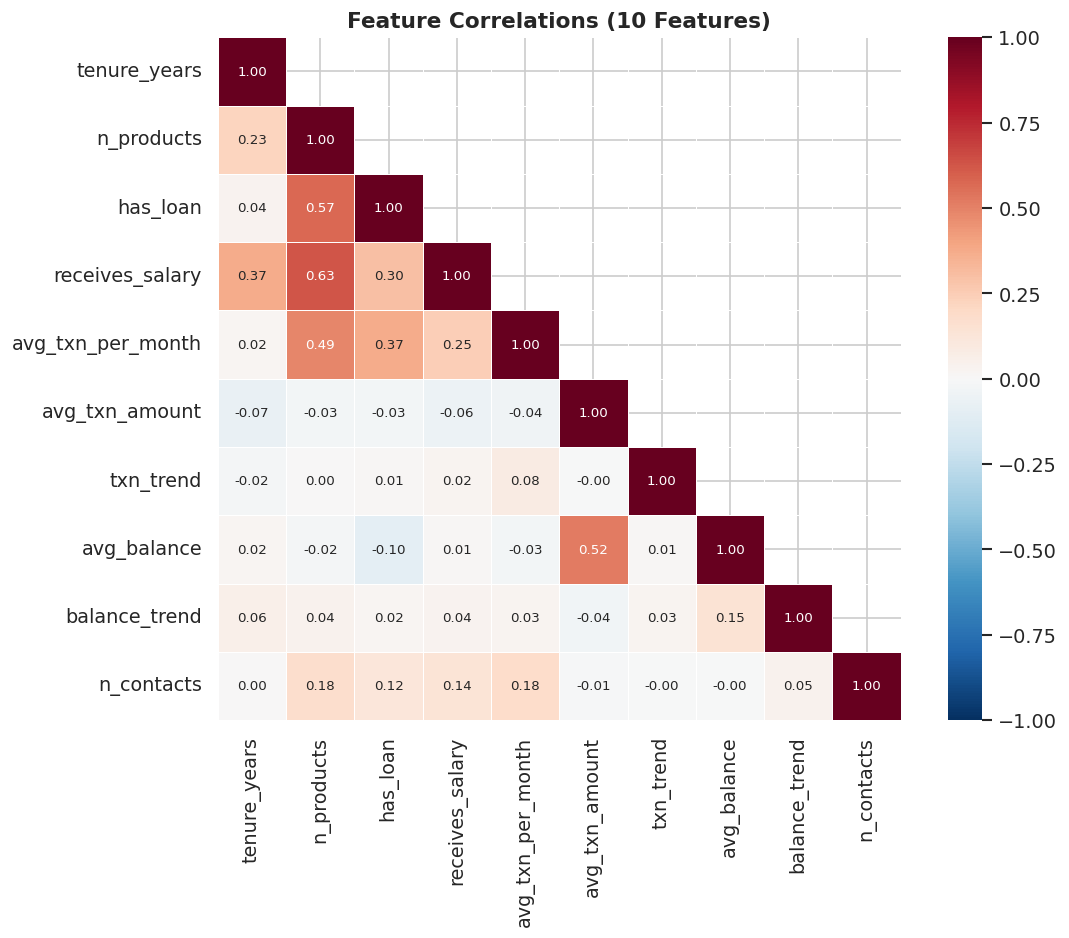

In [10]:
FEATURE_COLS = ['tenure_years', 'n_products', 'has_loan', 'receives_salary',
                'avg_txn_per_month', 'avg_txn_amount', 'txn_trend',
                'avg_balance', 'balance_trend', 'n_contacts']

print('Feature statistics:')
print(feat[FEATURE_COLS + ['churned']].describe().round(3).to_string())
print(f'\nMissing values:')
print(feat[FEATURE_COLS].isnull().sum().to_string())

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = feat[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlations (10 Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# ── Export raw features ──
out = feat[['client_id'] + FEATURE_COLS + ['churned']].copy()
out_path = PROCESSED / 'churn_features_raw.csv'
out.to_csv(out_path, index=False)
print(f'Exported: {out_path}')
print(f'  Shape: {out.shape}')
print(f'  Churn rate: {out["churned"].mean():.1%}')

Exported: ../data/processed/churn_features_raw.csv
  Shape: (7805, 12)
  Churn rate: 1.7%
